In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

print("Python environment is ready.")

Python environment is ready.


In [2]:
data_folder = Path(".")

csv_files = sorted(data_folder.glob("*.csv"))

print(f"CSV files found: {len(csv_files)}")

for file in csv_files:
    print(file.name)

CSV files found: 12
202509-divvy-tripdata.csv
202510-divvy-tripdata.csv
202511-divvy-tripdata.csv
202512-divvy-tripdata.csv
202601-divvy-tripdata.csv
202602-divvy-tripdata.csv
202603-divvy-tripdata.csv
202604-divvy-tripdata.csv
202605-divvy-tripdata.csv
202606-divvy-tripdata.csv
202607-divvy-tripdata.csv
202608-divvy-tripdata.csv


In [3]:
sample = pd.read_csv(csv_files[0], nrows=5)

print("Columns:")
print(sample.columns.tolist())

sample

Columns:
['ride_id', 'rideable_type', 'started_at', 'ended_at', 'start_station_name', 'start_station_id', 'end_station_name', 'end_station_id', 'start_lat', 'start_lng', 'end_lat', 'end_lng', 'member_casual']


,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,B0AD82B8A2556E7C,electric_bike,2025-09-01 12:05:13.323,2025-09-01 12:25:19.273,NaN,NaN,NaN,NaN,41.91,-87.63,41.96,-87.64,member
1,DCC4ABF0F7DCCE6A,electric_bike,2025-09-01 01:41:00.775,2025-09-01 01:48:59.228,NaN,NaN,NaN,NaN,41.95,-87.67,41.95,-87.65,member
2,C27785FFE7568433,electric_bike,2025-09-01 07:16:13.921,2025-09-01 07:39:51.831,NaN,NaN,NaN,NaN,41.94,-87.65,41.98,-87.65,member
3,812DB2D3AD2F18EB,electric_bike,2025-09-01 09:31:36.294,2025-09-01 09:49:08.022,NaN,NaN,NaN,NaN,41.98,-87.65,41.94,-87.65,member
4,61F6BD3174DC4E84,electric_bike,2025-09-26 08:51:58.069,2025-09-26 09:07:29.290,NaN,NaN,NaN,NaN,41.90,-87.69,41.87,-87.65,member


In [4]:
columns_needed = [
    "ride_id",
    "rideable_type",
    "started_at",
    "ended_at",
    "member_casual"
]

monthly_data = []

for file in csv_files:
    month = pd.read_csv(
        file,
        usecols=columns_needed,
        parse_dates=["started_at", "ended_at"]
    )
    
    monthly_data.append(month)
    print(f"Loaded {file.name}: {len(month):,} rows")

raw_trips = pd.concat(monthly_data, ignore_index=True)

del monthly_data
del month

print(f"\nCombined raw rows: {len(raw_trips):,}")

Loaded 202509-divvy-tripdata.csv: 714,759 rows
Loaded 202510-divvy-tripdata.csv: 646,039 rows
Loaded 202511-divvy-tripdata.csv: 356,628 rows
Loaded 202512-divvy-tripdata.csv: 140,534 rows
Loaded 202601-divvy-tripdata.csv: 137,787 rows
Loaded 202602-divvy-tripdata.csv: 201,450 rows
Loaded 202603-divvy-tripdata.csv: 317,037 rows
Loaded 202604-divvy-tripdata.csv: 448,252 rows
Loaded 202605-divvy-tripdata.csv: 653,704 rows
Loaded 202606-divvy-tripdata.csv: 762,550 rows
Loaded 202607-divvy-tripdata.csv: 869,051 rows
Loaded 202608-divvy-tripdata.csv: 868,191 rows

Combined raw rows: 6,115,982


In [5]:
raw_row_count = len(raw_trips)

# Remove rows missing required fields
clean_trips = raw_trips.dropna(
    subset=["ride_id", "started_at", "ended_at", "member_casual"]
).copy()

# Keep valid rider types
clean_trips = clean_trips[
    clean_trips["member_casual"].isin(["member", "casual"])
]

# Sort and remove duplicate ride IDs
clean_trips = clean_trips.sort_values(
    ["ride_id", "started_at", "ended_at"]
)

clean_trips = clean_trips.drop_duplicates(
    subset="ride_id",
    keep="first"
)

# Calculate ride length in minutes
clean_trips["ride_length"] = (
    clean_trips["ended_at"] - clean_trips["started_at"]
).dt.total_seconds() / 60

# Keep valid durations and analysis dates
clean_trips = clean_trips[
    clean_trips["ride_length"].between(1, 1440)
    & (clean_trips["started_at"] >= "2025-09-01")
    & (clean_trips["started_at"] < "2026-09-01")
].copy()

# Create analysis fields
clean_trips["day_of_week"] = (
    (clean_trips["started_at"].dt.dayofweek + 1) % 7
) + 1

clean_trips["day_name"] = clean_trips["started_at"].dt.day_name()
clean_trips["ride_month"] = clean_trips["started_at"].dt.strftime("%Y-%m")
clean_trips["start_hour"] = clean_trips["started_at"].dt.hour

print(f"Original rows: {raw_row_count:,}")
print(f"Clean rows: {len(clean_trips):,}")
print(f"Rows removed: {raw_row_count - len(clean_trips):,}")

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [6]:
# Convert timestamp text to datetime
clean_trips["started_at"] = pd.to_datetime(
    clean_trips["started_at"],
    format="mixed",
    errors="coerce"
)

clean_trips["ended_at"] = pd.to_datetime(
    clean_trips["ended_at"],
    format="mixed",
    errors="coerce"
)

# Remove any timestamps that could not be converted
clean_trips = clean_trips.dropna(
    subset=["started_at", "ended_at"]
).copy()

# Calculate ride length in minutes
clean_trips["ride_length"] = (
    clean_trips["ended_at"] - clean_trips["started_at"]
).dt.total_seconds() / 60000

# Apply duration and analysis-period filters
clean_trips = clean_trips[
    clean_trips["ride_length"].between(1, 1440)
    & (clean_trips["started_at"] >= pd.Timestamp("2025-09-01"))
    & (clean_trips["started_at"] < pd.Timestamp("2026-09-01"))
].copy()

# Create analysis fields
clean_trips["day_of_week"] = clean_trips["started_at"].dt.dayofweek + 1
clean_trips["day_name"] = clean_trips["started_at"].dt.day_name()
clean_trips["ride_month"] = clean_trips["started_at"].dt.strftime("%Y-%m")
clean_trips["start_hour"] = clean_trips["started_at"].dt.hour

print(f"Original rows: {len(raw_trips):,}")
print(f"Clean rows: {len(clean_trips):,}")
print(f"Rows removed: {len(raw_trips) - len(clean_trips):,}")

Original rows: 6,115,982
Clean rows: 6,205
Rows removed: 6,109,777


In [5]:
# Start again from the complete raw dataset
clean_trips = raw_trips.copy()

# Convert timestamp columns
clean_trips["started_at"] = pd.to_datetime(
    clean_trips["started_at"],
    format="mixed",
    errors="coerce"
)

clean_trips["ended_at"] = pd.to_datetime(
    clean_trips["ended_at"],
    format="mixed",
    errors="coerce"
)

# Remove missing required values
clean_trips = clean_trips.dropna(
    subset=["ride_id", "started_at", "ended_at", "member_casual"]
)

# Keep valid rider types
clean_trips = clean_trips[
    clean_trips["member_casual"].isin(["member", "casual"])
].copy()

# Removeापन duplicate ride IDs
clean_trips = (
    clean_trips
    .sort_values(["ride_id", "started_at", "ended_at"])
    .drop_duplicates(subset="ride_id", keep="first")
)

# Convert seconds to minutes correctly
clean_trips["ride_length"] = (
    clean_trips["ended_at"] - clean_trips["started_at"]
).dt.total_seconds() / 60

# Apply ride-length and date filters
clean_trips = clean_trips[
    clean_trips["ride_length"].between(1, 1440)
    & (clean_trips["started_at"] >= pd.Timestamp("2025-09-01"))
    & (clean_trips["started_at"] < pd.Timestamp("2026-09-01"))
].copy()

# Create analysis fields
clean_trips["day_of_week"] = (
    (clean_trips["started_at"].dt.dayofweek + 1) % 7
) + 1

clean_trips["day_name"] = clean_trips["started_at"].dt.day_name()
clean_trips["ride_month"] = clean_trips["started_at"].dt.strftime("%Y-%m")
clean_trips["start_hour"] = clean_trips["started_at"].dt.hour

print(f"Original rows: {len(raw_trips):,}")
print(f"Clean rows: {len(clean_trips):,}")
print(f"Rows removed: {len(raw_trips) - len(clean_trips):,}")

Original rows: 6,115,982
Clean rows: 5,951,516
Rows removed: 164,466


In [6]:
original_rows = len(raw_trips)
clean_rows = len(clean_trips)
rows_removed = original_rows - clean_rows
percentage_removed = (rows_removed / original_rows) * 100

missing_required = clean_trips[
    ["ride_id", "started_at", "ended_at", "member_casual"]
].isna().any(axis=1).sum()

duplicate_ride_ids = clean_trips["ride_id"].duplicated().sum()

invalid_rider_types = (
    ~clean_trips["member_casual"].isin(["member", "casual"])
).sum()

invalid_ride_lengths = (
    ~clean_trips["ride_length"].between(1, 1440)
).sum()

outside_analysis_period = (
    (clean_trips["started_at"] < pd.Timestamp("2025-09-01"))
    | (clean_trips["started_at"] >= pd.Timestamp("2026-09-01"))
).sum()

print(f"Original rows: {original_rows:,}")
print(f"Clean rows: {clean_rows:,}")
print(f"Rows removed: {rows_removed:,}")
print(f"Percentage removed: {percentage_removed:.2f}%")
print(f"Missing required values: {missing_required:,}")
print(f"Duplicate ride IDs: {duplicate_ride_ids:,}")
print(f"Invalid rider types: {invalid_rider_types:,}")
print(f"Invalid ride lengths: {invalid_ride_lengths:,}")
print(f"Outside analysis period: {outside_analysis_period:,}")

Original rows: 6,115,982
Clean rows: 5,951,516
Rows removed: 164,466
Percentage removed: 2.69%
Missing required values: 0
Duplicate ride IDs: 0
Invalid rider types: 0
Invalid ride lengths: 0
Outside analysis period: 0


In [7]:
mean_ride_length = clean_trips["ride_length"].mean()
maximum_ride_length = clean_trips["ride_length"].max()

day_counts = (
    clean_trips
    .groupby(["day_of_week", "day_name"])
    .size()
    .reset_index(name="ride_count")
    .sort_values("ride_count", ascending=False)
)

mode_day = day_counts.iloc[0]

print(f"Mean ride length: {mean_ride_length:.2f} minutes")
print(f"Maximum ride length: {maximum_ride_length:.2f} minutes")
print(f"Most popular day: {mode_day['day_name']}")
print(f"Day number: {mode_day['day_of_week']}")
print(f"Rides on most popular day: {mode_day['ride_count']:,.0f}")

Mean ride length: 14.38 minutes
Maximum ride length: 1439.98 minutes
Most popular day: Saturday
Day number: 7
Rides on most popular day: 929,681


In [8]:
rider_summary = (
    clean_trips
    .groupby("member_casual")
    .agg(
        total_rides=("ride_id", "count"),
        average_ride_length_minutes=("ride_length", "mean")
    )
    .reset_index()
)

rider_summary["percentage_of_rides"] = (
    rider_summary["total_rides"]
    / rider_summary["total_rides"].sum()
    * 100
)

rider_summary["average_ride_length_minutes"] = (
    rider_summary["average_ride_length_minutes"].round(2)
)

rider_summary["percentage_of_rides"] = (
    rider_summary["percentage_of_rides"].round(2)
)

rider_summary

,member_casual,total_rides,average_ride_length_minutes,percentage_of_rides
0,casual,2080836,18.41,34.96
1,member,3870680,12.22,65.04


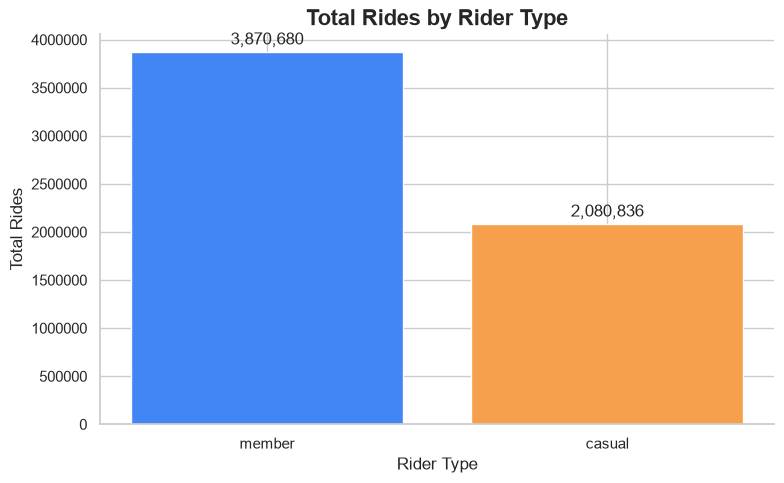

In [9]:
# Arrange categories consistently
plot_data = (
    rider_summary
    .set_index("member_casual")
    .loc[["member", "casual"]]
    .reset_index()
)

# Create chart
sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plot_data["member_casual"],
    plot_data["total_rides"],
    color=["#4285F4", "#F6A04D"]
)

ax.set_title("Total Rides by Rider Type", fontsize=16, weight="bold")
ax.set_xlabel("Rider Type")
ax.set_ylabel("Total Rides")

ax.bar_label(
    bars,
    labels=[f"{value:,.0f}" for value in plot_data["total_rides"]],
    padding=3
)

ax.ticklabel_format(style="plain", axis="y")
sns.despine()
plt.tight_layout()

# Save chart
output_folder = Path("../04_Visualizations")
output_folder.mkdir(exist_ok=True)

plt.savefig(
    output_folder / "Python_01_Total_Rides_by_Rider_Type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

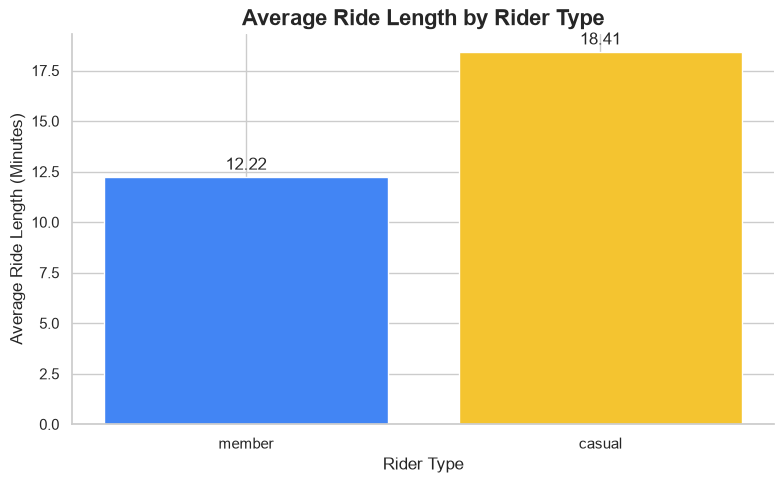

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

bars = ax.bar(
    plot_data["member_casual"],
    plot_data["average_ride_length_minutes"],
    color=["#4285F4", "#F4C430"]
)

ax.set_title(
    "Average Ride Length by Rider Type",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Rider Type")
ax.set_ylabel("Average Ride Length (Minutes)")

ax.bar_label(
    bars,
    labels=[
        f"{value:.2f}"
        for value in plot_data["average_ride_length_minutes"]
    ],
    padding=3
)

sns.despine()
plt.tight_layout()

plt.savefig(
    output_folder / "Python_02_Average_Ride_Length_by_Rider_Type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

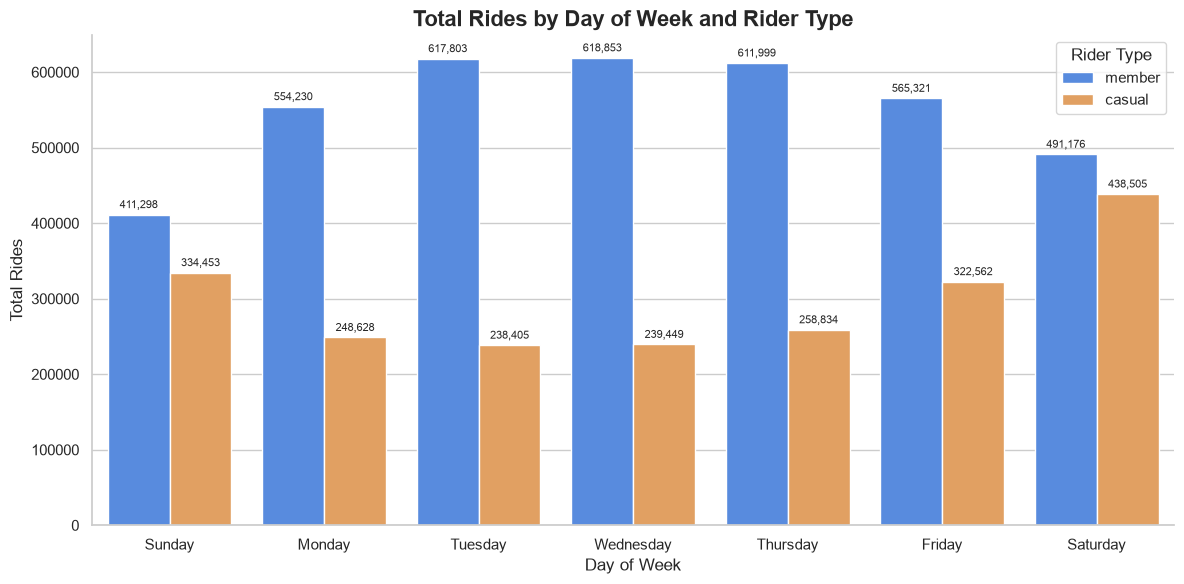

In [11]:
day_order = [
    "Sunday",
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday"
]

weekday_summary = (
    clean_trips
    .groupby(["day_of_week", "day_name", "member_casual"])
    .size()
    .reset_index(name="total_rides")
)

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=weekday_summary,
    x="day_name",
    y="total_rides",
    hue="member_casual",
    order=day_order,
    hue_order=["member", "casual"],
    palette={
        "member": "#4285F4",
        "casual": "#F6A04D"
    },
    ax=ax
)

ax.set_title(
    "Total Rides by Day of Week and Rider Type",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Day of Week")
ax.set_ylabel("Total Rides")
ax.legend(title="Rider Type")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[f"{value:,.0f}" for value in container.datavalues],
        padding=3,
        fontsize=8
    )

ax.ticklabel_format(style="plain", axis="y")
sns.despine()
plt.tight_layout()

plt.savefig(
    output_folder / "Python_03_Rides_by_Day_of_Week.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

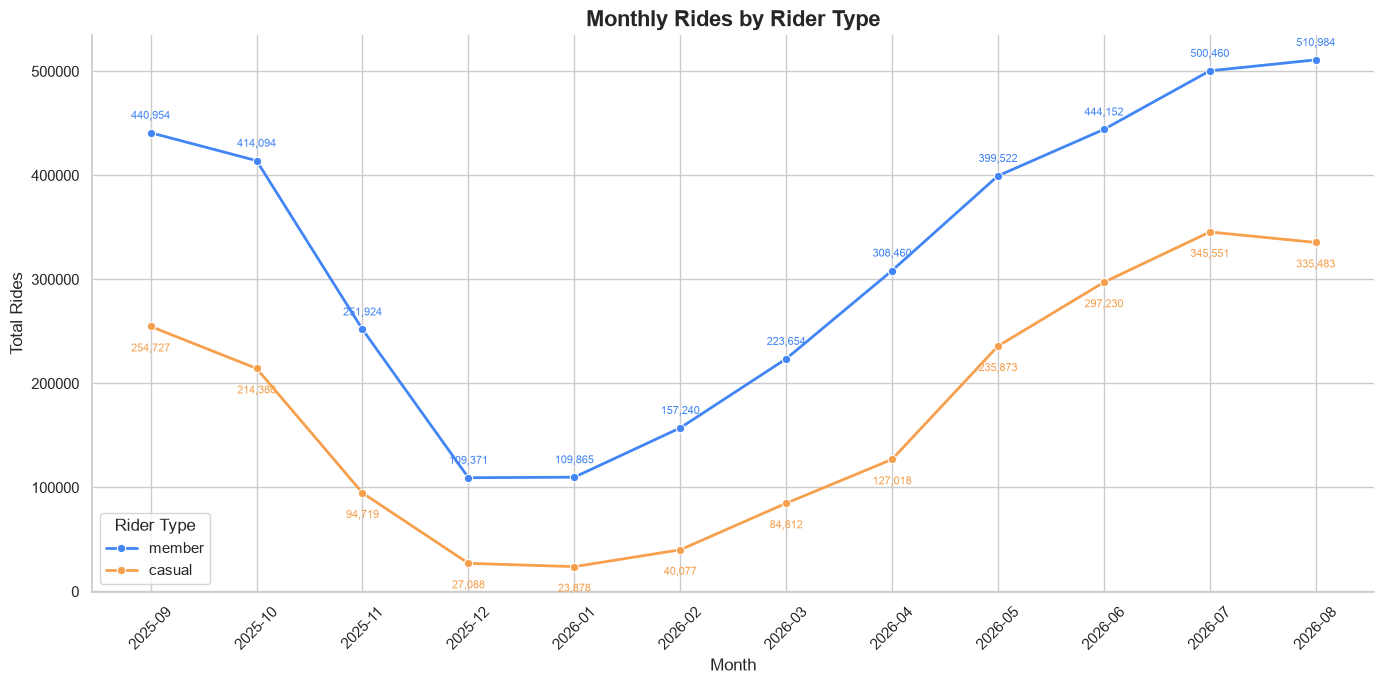

In [12]:
monthly_summary = (
    clean_trips
    .groupby(["ride_month", "member_casual"])
    .size()
    .reset_index(name="total_rides")
    .sort_values("ride_month")
)

fig, ax = plt.subplots(figsize=(14, 7))

sns.lineplot(
    data=monthly_summary,
    x="ride_month",
    y="total_rides",
    hue="member_casual",
    hue_order=["member", "casual"],
    palette={
        "member": "#4285F4",
        "casual": "#F6A04D"
    },
    marker="o",
    linewidth=2,
    ax=ax
)

for rider_type, color, offset in [
    ("member", "#4285F4", 10),
    ("casual", "#F6A04D", -18)
]:
    rider_data = monthly_summary[
        monthly_summary["member_casual"] == rider_type
    ]

    for _, row in rider_data.iterrows():
        ax.annotate(
            f"{row['total_rides']:,.0f}",
            (row["ride_month"], row["total_rides"]),
            textcoords="offset points",
            xytext=(0, offset),
            ha="center",
            fontsize=8,
            color=color
        )

ax.set_title(
    "Monthly Rides by Rider Type",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Month")
ax.set_ylabel("Total Rides")
ax.legend(title="Rider Type")
ax.tick_params(axis="x", rotation=45)
ax.ticklabel_format(style="plain", axis="y")

sns.despine()
plt.tight_layout()

plt.savefig(
    output_folder / "Python_04_Monthly_Ride_Trends.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

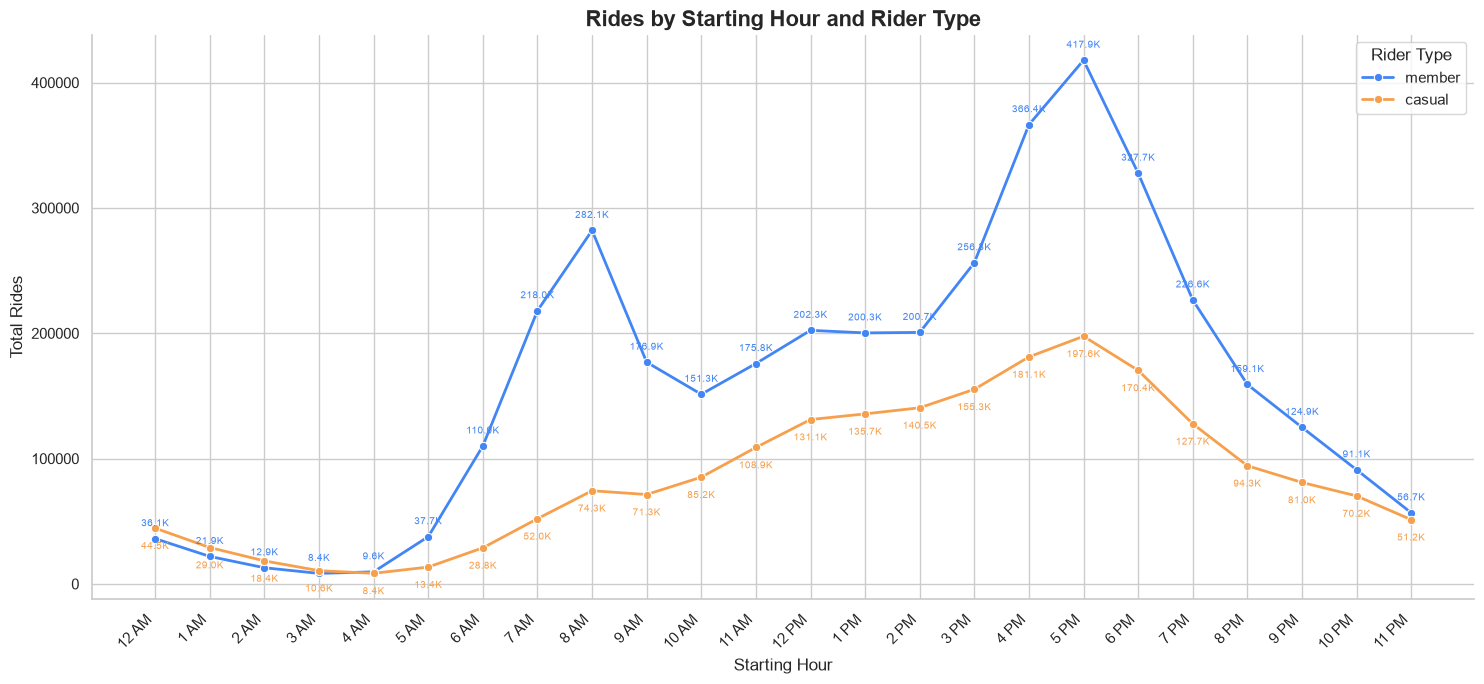

In [13]:
hourly_summary = (
    clean_trips
    .groupby(["start_hour", "member_casual"])
    .size()
    .reset_index(name="total_rides")
    .sort_values("start_hour")
)

hour_labels = [
    "12 AM", "1 AM", "2 AM", "3 AM", "4 AM", "5 AM",
    "6 AM", "7 AM", "8 AM", "9 AM", "10 AM", "11 AM",
    "12 PM", "1 PM", "2 PM", "3 PM", "4 PM", "5 PM",
    "6 PM", "7 PM", "8 PM", "9 PM", "10 PM", "11 PM"
]

fig, ax = plt.subplots(figsize=(15, 7))

sns.lineplot(
    data=hourly_summary,
    x="start_hour",
    y="total_rides",
    hue="member_casual",
    hue_order=["member", "casual"],
    palette={
        "member": "#4285F4",
        "casual": "#F6A04D"
    },
    marker="o",
    linewidth=2,
    ax=ax
)

for rider_type, color, offset in [
    ("member", "#4285F4", 9),
    ("casual", "#F6A04D", -15)
]:
    rider_data = hourly_summary[
        hourly_summary["member_casual"] == rider_type
    ]

    for _, row in rider_data.iterrows():
        ax.annotate(
            f"{row['total_rides'] / 1000:.1f}K",
            (row["start_hour"], row["total_rides"]),
            textcoords="offset points",
            xytext=(0, offset),
            ha="center",
            fontsize=7,
            color=color
        )

ax.set_title(
    "Rides by Starting Hour and Rider Type",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Starting Hour")
ax.set_ylabel("Total Rides")
ax.set_xticks(range(24))
ax.set_xticklabels(hour_labels, rotation=45, ha="right")
ax.legend(title="Rider Type")
ax.ticklabel_format(style="plain", axis="y")

sns.despine()
plt.tight_layout()

plt.savefig(
    output_folder / "Python_05_Rides_by_Starting_Hour.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

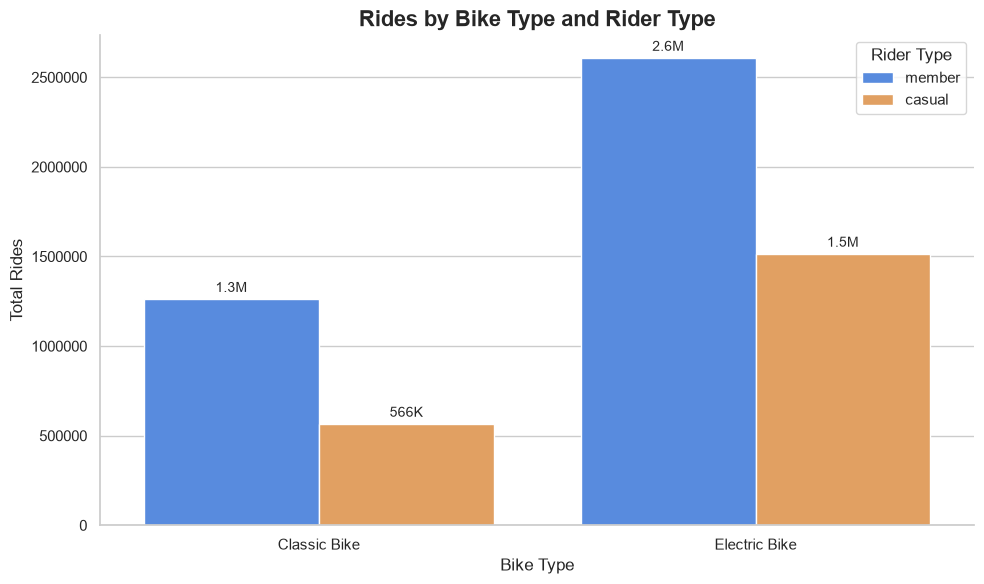

In [15]:
bike_summary = (
    clean_trips
    .groupby(["rideable_type", "member_casual"])
    .size()
    .reset_index(name="total_rides")
)

bike_order = ["classic_bike", "electric_bike"]

fig, ax = plt.subplots(figsize=(10, 6))

sns.barplot(
    data=bike_summary,
    x="rideable_type",
    y="total_rides",
    hue="member_casual",
    order=bike_order,
    hue_order=["member", "casual"],
    palette={
        "member": "#4285F4",
        "casual": "#F6A04D"
    },
    ax=ax
)

ax.set_title(
    "Rides by Bike Type and Rider Type",
    fontsize=16,
    weight="bold"
)
ax.set_xlabel("Bike Type")
ax.set_ylabel("Total Rides")
ax.set_xticks(
    [0,1],
    labels=["Classic Bike", "Electric Bike"])
ax.legend(title="Rider Type")

for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{value / 1_000_000:.1f}M"
            if value >= 1_000_000
            else f"{value / 1_000:.0f}K"
            for value in container.datavalues
        ],
        padding=3,
        fontsize=10
    )

ax.ticklabel_format(style="plain", axis="y")
sns.despine()
plt.tight_layout()

plt.savefig(
    output_folder / "Python_06_Rides_by_Bike_Type.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [16]:
clean_trips.to_parquet(
    "clean_trips_python.parquet",
    index=False
)

print("Clean Python dataset saved successfully.")

Clean Python dataset saved successfully.


In [4]:
# Load the validated clean dataset
clean_trips = pd.read_parquet("clean_trips_python.parquet")

# Create one compact Tableau-ready dataset
tableau_data = (
    clean_trips
    .groupby(
        [
            "member_casual",
            "rideable_type",
            "day_of_week",
            "day_name",
            "ride_month",
            "start_hour"
        ],
        observed=True
    )
    .agg(
        total_rides=("ride_id", "count"),
        total_ride_minutes=("ride_length", "sum")
    )
    .reset_index()
)

# Save as CSV for Tableau Public
tableau_data.to_csv(
    "Cyclistic_Tableau_Data.csv",
    index=False
)

print(f"Tableau rows created: {len(tableau_data):,}")
print("Cyclistic_Tableau_Data.csv saved successfully.")

Tableau rows created: 8,063
Cyclistic_Tableau_Data.csv saved successfully.


In [3]:
import pandas as pd

In [5]:
from pathlib import Path
import pandas as pd

data_folder = Path(".")
csv_files = sorted(data_folder.glob("*-divvy-tripdata.csv"))

station_parts = []

for file in csv_files:
    rides = pd.read_csv(
        file,
        usecols=[
            "start_station_name",
            "start_lat",
            "start_lng",
            "end_station_name",
            "end_lat",
            "end_lng",
            "member_casual"
        ]
    )

    # Starting stations
    starts = rides[
        [
            "start_station_name",
            "start_lat",
            "start_lng",
            "member_casual"
        ]
    ].copy()

    starts.columns = [
        "station_name",
        "latitude",
        "longitude",
        "member_casual"
    ]

    starts["station_type"] = "Start"

    # Ending stations
    ends = rides[
        [
            "end_station_name",
            "end_lat",
            "end_lng",
            "member_casual"
        ]
    ].copy()

    ends.columns = [
        "station_name",
        "latitude",
        "longitude",
        "member_casual"
    ]

    ends["station_type"] = "End"

    stations = pd.concat([starts, ends], ignore_index=True)

    stations["latitude"] = pd.to_numeric(
        stations["latitude"], errors="coerce"
    )
    stations["longitude"] = pd.to_numeric(
        stations["longitude"], errors="coerce"
    )

    stations = stations.dropna(
        subset=[
            "station_name",
            "latitude",
            "longitude",
            "member_casual"
        ]
    )

    monthly_summary = (
        stations
        .groupby(
            ["station_type", "station_name", "member_casual"],
            as_index=False
        )
        .agg(
            total_rides=("station_name", "size"),
            latitude_sum=("latitude", "sum"),
            longitude_sum=("longitude", "sum")
        )
    )

    station_parts.append(monthly_summary)

tableau_stations = (
    pd.concat(station_parts, ignore_index=True)
    .groupby(
        ["station_type", "station_name", "member_casual"],
        as_index=False
    )
    .agg(
        total_rides=("total_rides", "sum"),
        latitude_sum=("latitude_sum", "sum"),
        longitude_sum=("longitude_sum", "sum")
    )
)

tableau_stations["latitude"] = (
    tableau_stations["latitude_sum"]
    / tableau_stations["total_rides"]
)

tableau_stations["longitude"] = (
    tableau_stations["longitude_sum"]
    / tableau_stations["total_rides"]
)

tableau_stations = tableau_stations.drop(
    columns=["latitude_sum", "longitude_sum"]
)

tableau_stations.to_csv(
    "Cyclistic_Tableau_Stations.csv",
    index=False
)

print(f"Station rows created: {len(tableau_stations):,}")
print("Cyclistic_Tableau_Stations.csv saved successfully.")

Station rows created: 7,599
Cyclistic_Tableau_Stations.csv saved successfully.
